# Brain tissue lymphocytes validation analysis

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
  library(ggExtra)
  library(igraph)
  library(ggraph)
  library(patchwork)
  library(cowplot)
})

In [2]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [3]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/external/lesion_rims/annotated/lesion_rims_lymphocytes_filtered.qs", nthreads = getOption("hpc.ncpus", 1))

### Program scores

In [ ]:
gep.usage <- set_names("B", "T") %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/external/lesion_rims/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/external/lesion_rims/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`
New names:
* `` -> `...1`


# Compute UMAP

In [521]:
seu <- RunUMAP(
  seu,
  reduction = "integrated.rna",
  dims = 1:50,
  metric = "cosine",
  n.neighbors = 30L,
  min.dist = 0.3,
  spread = 1,
  n.epochs = 500L,
  return.model = TRUE
)

UMAP will return its model

13:45:48 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

13:45:48 Read 1417 rows and found 50 numeric columns

13:45:48 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

13:45:48 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%



[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:45:48 Writing NN index file to temp file /tmp/RtmpBISU6x/filebc8c224525808

13:45:48 Searching Annoy index using 16 threads, search_k = 3000

13:45:48 Annoy recall = 100%

13:45:49 Commencing smooth kNN distance calibration using 16 threads
 with target n_neighbors = 30

13:45:50 Initializing from normalized Laplacian + noise (using RSpectra)

13:45:50 Commencing optimization for 500 epochs, with 67966 positive edges

13:45:53 Optimization finished



# Custom colour palettes

### Clusters

In [5]:
cluster.main.pal <- c(
  B = pals::brewer.reds(100)[90],
  DC = pals::brewer.greys(100)[90],
  Mono = pals::brewer.purples(100)[90],
  ILC = pals::brewer.oranges(100)[50],
  NK = pals::brewer.blues(100)[90],
  T = pals::brewer.greens(100)[90]
)

In [6]:
cluster.coarse.pal <- c(
  B_naive = pals::brewer.reds(5)[3],
  B_memory = pals::brewer.reds(5)[2],
  B_plasma = pals::brewer.reds(5)[4],
  DC_AXL_SIGLEC6 = pals::brewer.greys(5)[3],
  DC_conventional = pals::brewer.greys(5)[2],
  DC_plasmacytoid = pals::brewer.greys(5)[4],
  ILC = pals::brewer.oranges(100)[50],
  Mono_CD14 = pals::brewer.purples(5)[2],
  Mono_CD16 = pals::brewer.purples(5)[4],
  NK_CD56dim = pals::brewer.blues(5)[4],
  NK_CD56bright = pals::brewer.blues(5)[2],
  T_CD4_naive = pals::brewer.greens(10)[2],
  T_CD4_memory = pals::brewer.greens(10)[7],
  T_regulatory_naive = pals::brewer.greens(10)[5],
  T_regulatory_memory = pals::brewer.greens(10)[9],
  T_CD8_naive = pals::brewer.greens(10)[10],
  T_CD8_memory = pals::brewer.greens(10)[6],
  T_MAIT = pals::brewer.greens(10)[4],
  T_GD = pals::brewer.greens(10)[8],
  T_DN = pals::brewer.greens(10)[3]
)

In [7]:
cluster.pal <- c(cluster.main.pal, cluster.coarse.pal)

# Visualise integration

Inferred data type as 'discrete'. To override, set type explicitly.



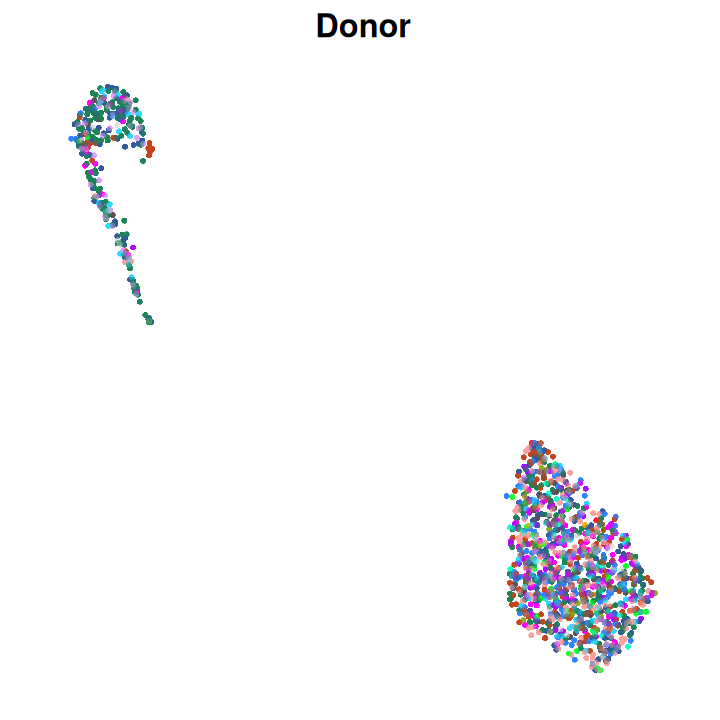

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

plot <- embedding.plot(
  seu,
  colour = "donor_id",
  cmap = pals::polychrome(18) |> set_names(sort(unique(seu$donor_id))),
  labs = list(title = "Donor"),
  show.legend = FALSE,
  rasterise = TRUE,
  size.adj = 10,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/lesion_rims_lymphocytes_all_donor_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



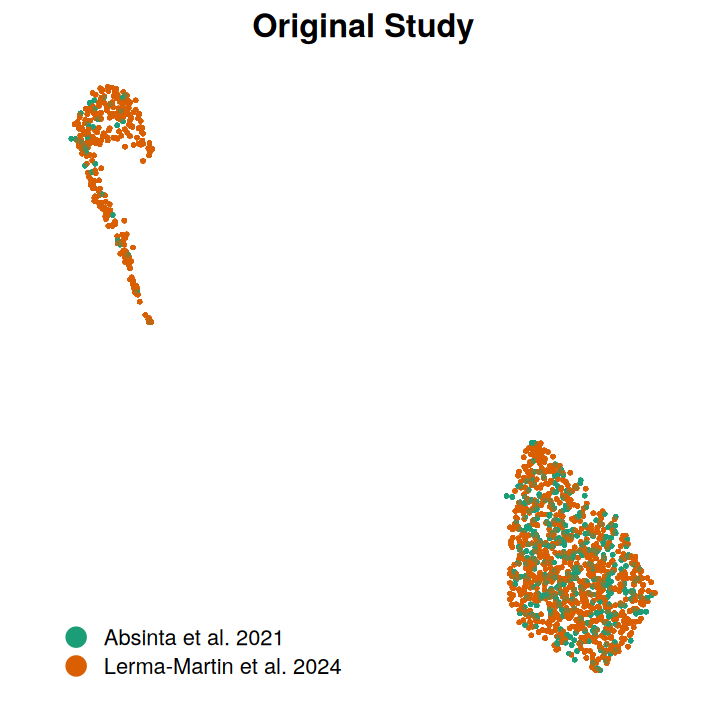

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

plot <- embedding.plot(
  seu,
  colour = "study",
  cmap = pals::brewer.dark2(3)[1:2] |> set_names(sort(unique(seu$study))),
  labs = list(title = "Original Study", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 10,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 2)) +
  inset.legend(location = "bottomleft") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/lesion_rims_lymphocytes_all_study_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



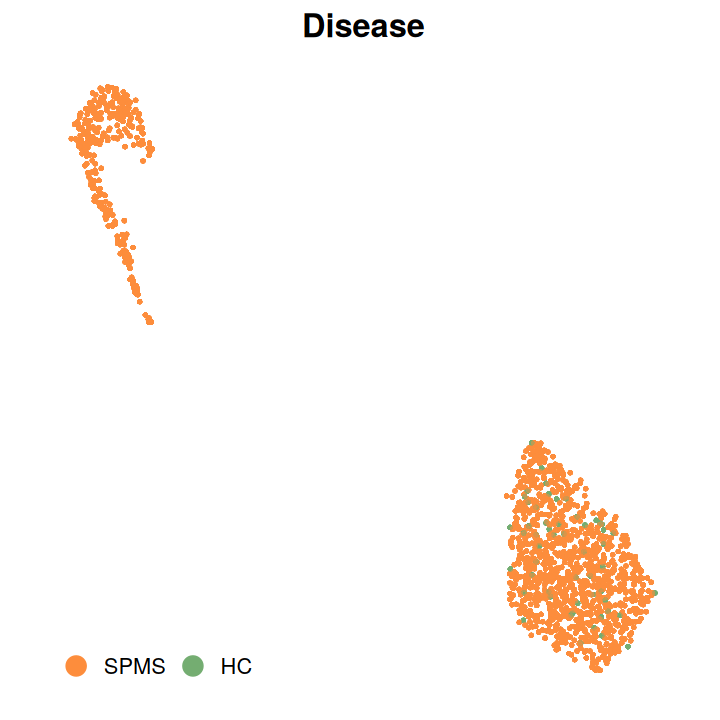

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "diagnosis")) %>%
  mutate(diagnosis = if_else(diagnosis == "Control", "HC", "SPMS") |> factor(levels = c("SPMS", "HC")))

plot <- embedding.plot(
  data,
  colour = "diagnosis",
  cmap = c(SPMS = "#FD8D3C", HC = "#74ad71"),
  labs = list(title = "Disease", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 10,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 1)) +
  inset.legend(location = "bottomleft") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/lesion_rims_lymphocytes_all_disease_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Inferred data type as 'discrete'. To override, set type explicitly.



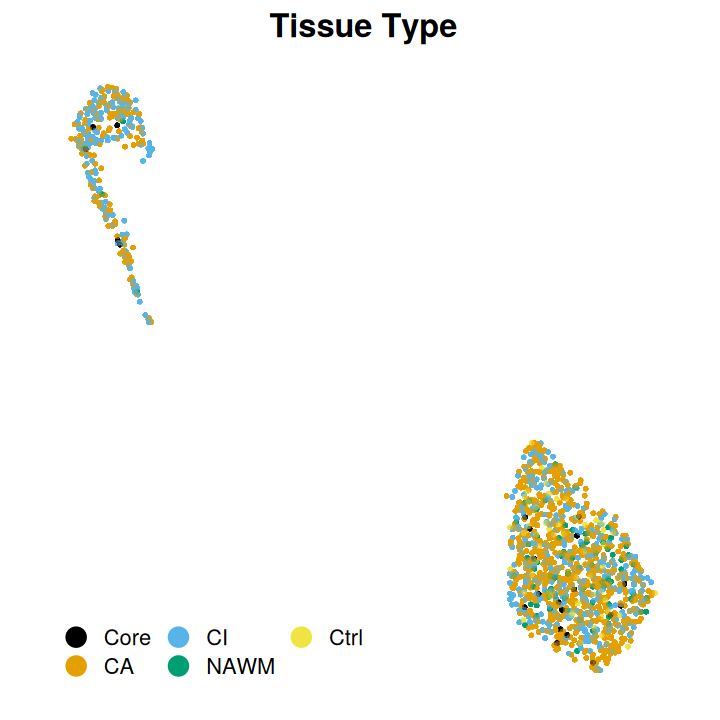

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "lesion_type")) %>%
  mutate(lesion_type = factor(lesion_type, levels = c("Core", "CA", "CI", "NAWM", "Ctrl")))

plot <- embedding.plot(
  data,
  colour = "lesion_type",
  cmap = pals::okabe(5) |> set_names(sort(unique(data$lesion_type))),
  labs = list(title = "Tissue Type", colour = NULL),
  show.legend = TRUE,
  rasterise = TRUE,
  size.adj = 10,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  guides(colour = guide_legend(override.aes = list(size = 5), nrow = 2)) +
  inset.legend(location = "bottomleft") +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/lesion_rims_lymphocytes_all_tissue_type_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise cell types

Inferred data type as 'discrete'. To override, set type explicitly.



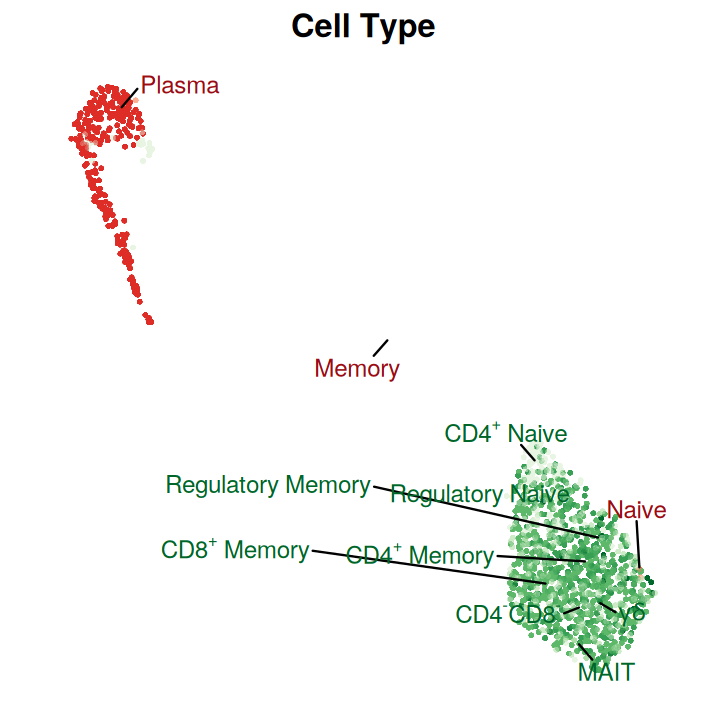

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "cluster_coarse", "cluster_main"))
labels <- data %>%
  group_by(cluster_coarse) %>%
  summarise(cluster_main = first(cluster_main)) %>%
  left_join(calculate.centroid.density(data, group.var = "cluster_coarse", x.var = "umap_1", y.var = "umap_2"), by = "cluster_coarse") %>%
  mutate(
    cluster_coarse = case_match(
      as.character(cluster_coarse),
      "B_naive" ~ "Naive",
      "B_memory" ~ "Memory",
      "B_plasma" ~ "Plasma",
      "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
      "DC_conventional" ~ "Conventional",
      "DC_plasmacytoid" ~ "Plasmacytoid",
      "ILC" ~ "ILC",
      "Mono_CD14" ~ "CD14^'+'",
      "Mono_CD16" ~ "CD16^'+'",
      "NK_CD56dim" ~ "CD56^dim",
      "NK_CD56bright" ~ "CD56^bright",
      "T_CD4_naive" ~ "CD4^'+'~Naive",
      "T_CD4_memory" ~ "CD4^'+'~Memory",
      "T_regulatory_naive" ~ "Regulatory~Naive",
      "T_regulatory_memory" ~ "Regulatory~Memory",
      "T_CD8_naive" ~ "CD8^'+'~Naive",
      "T_CD8_memory" ~ "CD8^'+'~Memory",
      "T_MAIT" ~ "MAIT",
      "T_GD" ~ "gamma*delta",
      "T_DN" ~ "CD4^'-'*CD8^'-'"
    )
  )

plot <- embedding.plot(data, colour = "cluster_coarse", cmap = cluster.pal, labs = list(title = "Cell Type", colour = NULL), show.legend = FALSE, rasterise = TRUE, size.adj = 10, alpha = 1, pixels = c(2048, 2048)) +
  ggrepel::geom_text_repel(
    data = labels,
    mapping = aes(x = x, y = y, colour = cluster_main, label = cluster_coarse),
    segment.colour = "black",
    box.padding = 0.75,
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0,
    seed = 42,
    parse = TRUE,
    show.legend = FALSE
  ) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/lesion_rims_lymphocytes_all_cell_type_umap.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# T cells

In [9]:
# Subset to T cells only
sub <- subset(seu, subset = cluster_main == "T")

In [ ]:
sub[["GEP"]] <- CreateAssayObject(data = gep.usage[["T"]])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


### Cell type composition

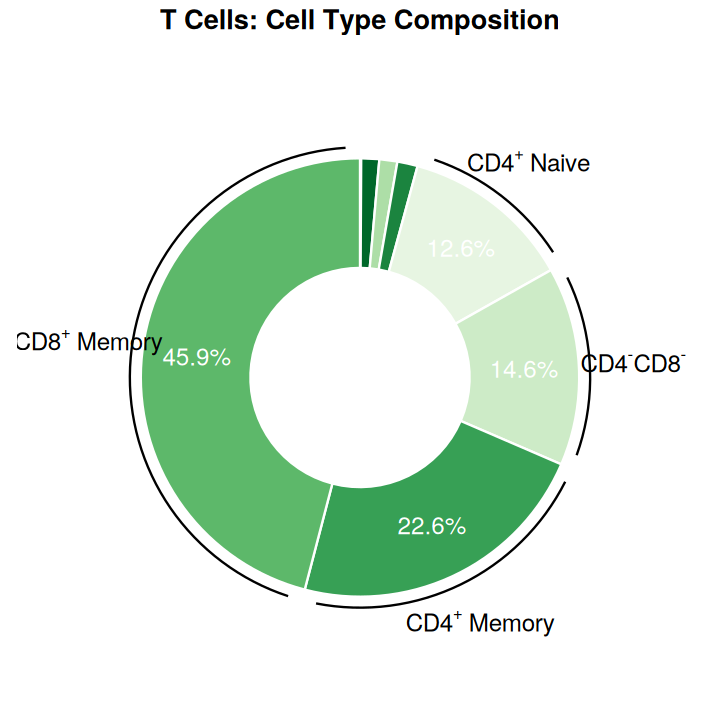

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(sub, vars = c("cluster_coarse", "cluster_fine")) %>%
  group_by(cluster_coarse) %>%
  summarise(prop = n() / nrow(.), .groups = "drop") %>%
  arrange(prop) %>%
  mutate(
    ymax = cumsum(prop),
    ymin = lag(ymax, default = 0),
    label = case_match(
      as.character(cluster_coarse),
      "T_CD4_naive" ~ "CD4^'+'~Naive",
      "T_CD4_memory" ~ "CD4^'+'~Memory",
      "T_regulatory_naive" ~ "Regulatory~Naive",
      "T_regulatory_memory" ~ "Regulatory~Memory",
      "T_CD8_naive" ~ "CD8^'+'~Naive",
      "T_CD8_memory" ~ "CD8^'+'~Memory",
      "T_MAIT" ~ "MAIT",
      "T_GD" ~ "gamma*delta",
      "T_DN" ~ "CD4^'-'*CD8^'-'"
    ),
    mid = (ymax + ymin) / 2
  )

plot <- ggplot(data, aes(ymin = ymin, ymax = ymax, fill = cluster_coarse)) +
  geom_rect(aes(xmin = 2, xmax = 4), colour = "white", show.legend = FALSE) +
  geom_segment(
    data = data %>% filter(prop > 0.02),
    mapping = aes(x = 4.2, xend = 4.2, y = ymin + 0.01, yend = ymax - 0.01),
  ) +
  geom_text(
    data = data %>% filter(prop > 0.02),
    aes(x = 3, y = mid, label = paste0(round(prop * 100, 1), "%")),
    colour = "white",
    size = 5,
    hjust = 0.5
  ) +
  geom_text(
    data = data %>% filter(prop > 0.02),
    aes(x = 5, y = mid, label = label),
    parse = TRUE, fontface = "bold", size = 5
  ) +
  labs(title = "T Cells: Cell Type Composition") +
  coord_polar(theta = "y") +
  xlim(0, 5) +
  scale_fill_manual(values = cluster.pal) +
  theme_void() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/lesion_rims_lymphocytes_t_cell_type_donut.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Intralesional niche T~c~1-TH signature comparison

In [12]:
chosen.gep <- Features(sub[["GEP"]])[c(13, 20, 30)]
chosen.gep

[1] "Th1-like (CXCR3/CCL5/ITGA4)"             
[2] "Cytotoxic Inflammatory (GZMK/EOMES/IFNG)"
[3] "Activation Signalling (IER2/CD69/CD83)"

In [13]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

In [ ]:
data <- FetchData(sub, vars = c("cluster_coarse", "diagnosis", "lesion_type", "program_score", "age", "sex", "donor_id")) %>%
  mutate(
    lesion_type = factor(lesion_type, levels = c("Core", "CA", "CI", "NAWM", "Ctrl"))
  ) %>%
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory"))

# *** TOO FEW CELLS PER DONOR TO AGGREGATE ***
# data.summary <- data %>%
#   group_by(lesion_type, donor_id) %>%
#   summarise(
#     n_cells = n(),
#     program_score = mean(program_score, na.rm = TRUE),
#     age = first(age),
#     sex = first(sex),
#     .groups = "drop"
#   ) %>%
#   filter(n_cells >= 10)

In [15]:
model <- lmerTest::lmer(
  program_score ~ lesion_type + age + sex + (1 | donor_id),
  data = data
)

In [16]:
emm <- emmeans::emmeans(model, ~lesion_type, lmer.df = "Satterthwaite")

contrasts <- list(
  "Core vs CA" = c(1, -1, 0, 0, 0),
  "Core vs CI" = c(1, 0, -1, 0, 0),
  "Core vs NAWM" = c(1, 0, 0, -1, 0),
  "Core vs Ctrl" = c(1, 0, 0, 0, -1),
  "CA vs CI" = c(0, 1, -1, 0, 0),
  "CA vs NAWM" = c(0, 1, 0, -1, 0),
  "CA vs Ctrl" = c(0, 1, 0, 0, -1),
  "CI vs NAWM" = c(0, 0, 1, -1, 0),
  "CI vs Ctrl" = c(0, 0, 1, 0, -1),
  "NAWM vs Ctrl" = c(0, 0, 0, 1, -1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 4)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = c(0.55, 0.65, 0.85, 1.05, 0.55, 0.75, 0.95, 0.55, 0.65, 0.55)
  )

In [17]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Core vs CA,-0.073886858,0.02424466,586.91056,-0.121503710,-0.02627001,-3.0475520,0.002410892,0.02410892,p = 0.0241 *,Core,CA,0.55
Core vs CI,-0.066298892,0.02592719,341.44214,-0.117296018,-0.01530177,-2.5571183,0.010986082,0.03407966,p = 0.0341 *,Core,CI,0.65
Core vs NAWM,-0.070452825,0.02628071,740.88404,-0.122046345,-0.01885930,-2.6807814,0.007508378,0.03407966,p = 0.0341 *,Core,NAWM,0.85
Core vs Ctrl,-0.012268698,0.03335658,120.87339,-0.078307545,0.05377015,-0.3678045,0.713662312,0.81576944,p = 0.816 ns,Core,Ctrl,1.05
CA vs CI,0.007587965,0.01271246,33.75924,-0.018253641,0.03342957,0.5968922,0.554561641,0.79223092,p = 0.792 ns,CA,CI,0.55
CA vs NAWM,0.003434033,0.01472137,220.32571,-0.025578688,0.03244675,0.2332686,0.815769438,0.81576944,p = 0.816 ns,CA,NAWM,0.75
CA vs Ctrl,0.061618159,0.02380734,37.65954,0.013408412,0.10982791,2.5882004,0.013631866,0.03407966,p = 0.0341 *,CA,Ctrl,0.95
CI vs NAWM,-0.004153933,0.01592959,116.92321,-0.035701871,0.02739401,-0.2607683,0.794729914,0.81576944,p = 0.816 ns,CI,NAWM,0.55
CI vs Ctrl,0.054030194,0.02389013,35.21139,0.005541062,0.10251933,2.2616117,0.030000067,0.05000011,p = 0.05 .,CI,Ctrl,0.65


In [18]:
contrasts <- list(
  "Core vs CA" = c(1, -1, -1, -1, 0),
  "NAWM vs Ctrl" = c(0, 1, 1, 1, -1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 4)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.55
  )

In [19]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Core vs CA,-0.3523790,0.03018962,115.57177,-0.4121756,-0.2925823,-11.67219,2.852917e-21,5.705835e-21,p = 5.71e-21 ***,Core,CA,0.55
NAWM vs Ctrl,0.3401103,0.03137636,18.73567,0.2743760,0.4058445,10.83970,1.648748e-09,1.648748e-09,p = 1.65e-09 ***,NAWM,Ctrl,0.55


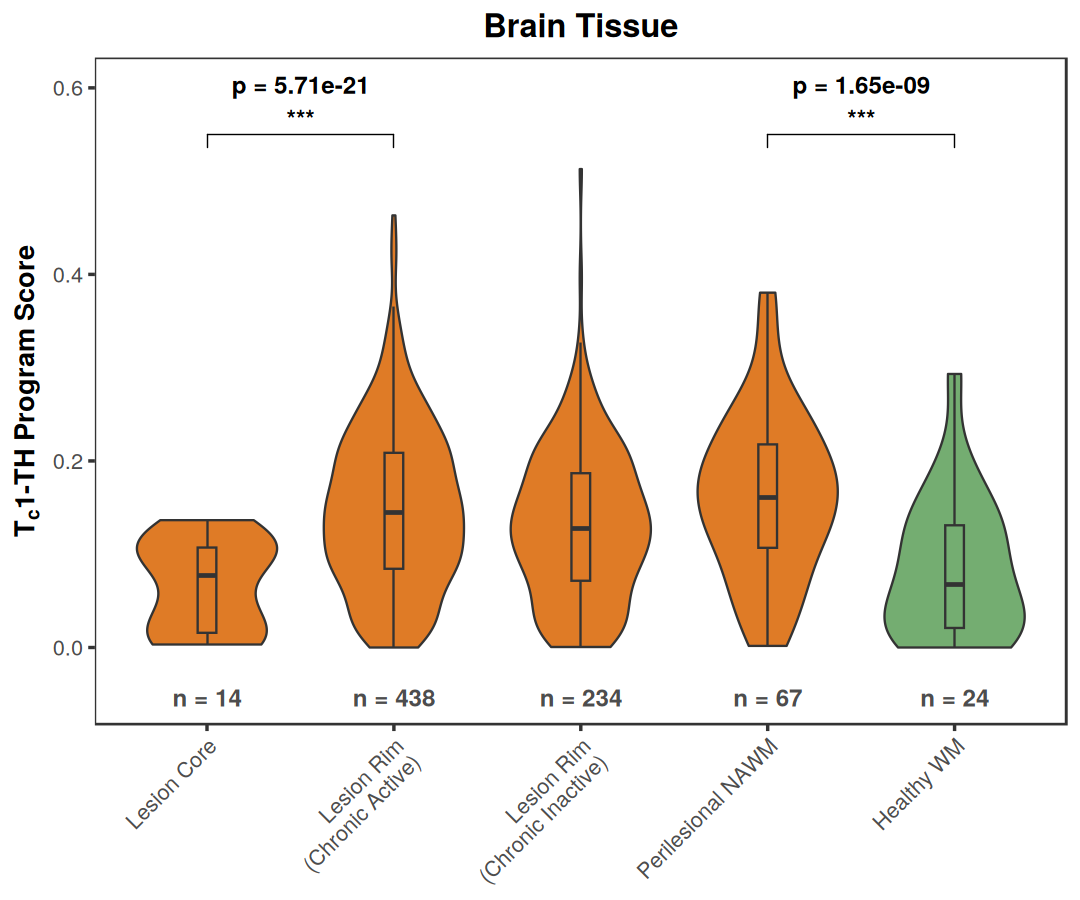

In [ ]:
options(repr.plot.width = 9, repr.plot.height = 7.5)

ggplot(data = data, mapping = aes(x = lesion_type, y = program_score)) +
  geom_violin(
    mapping = aes(fill = diagnosis),
    width = 0.75,
    scale = "width",
    trim = TRUE,
    alpha = 1
  ) +
  geom_boxplot(
    mapping = aes(fill = diagnosis),
    width = 0.1,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_text(
    data = data %>%
      group_by(lesion_type) %>%
      summarise(n = n(), .groups = "drop"),
    mapping = aes(x = lesion_type, y = -Inf, label = paste0("n = ", n)),
    vjust = -1,
    size = 5,
    color = "grey30",
    fontface = "bold"
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.025,
    bracket.shorten = 0
  ) +
  scale_x_discrete(
    labels = c(
      "Core" = "Lesion Core",
      "CA" = "Lesion Rim\n(Chronic Active)",
      "CI" = "Lesion Rim\n(Chronic Inactive)",
      "NAWM" = "Perilesional NAWM",
      "Ctrl" = "Healthy WM"
    )
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.15, 0.15))) +
  scale_fill_manual(values = c(SPMS = "#df7b26", Control = "#74ad71")) +
  labs(
    title = "Brain Tissue",
    x = NULL,
    y = expression(bold(T[c] * "1-" * TH ~ Program ~ Score))
  ) +
  theme_custom() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )

ggsave(
  filename = "../results/plots/lesion_rims_lymphocytes_tc1th_lesion_type_violin.pdf",
  width = 9,
  height = 7.5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# B cells

In [ ]:
# Subset to B cells only
sub <- subset(seu, subset = cluster_main == "B")

In [ ]:
sub[["GEP"]] <- CreateAssayObject(data = gep.usage[["B"]])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


### Cell type composition

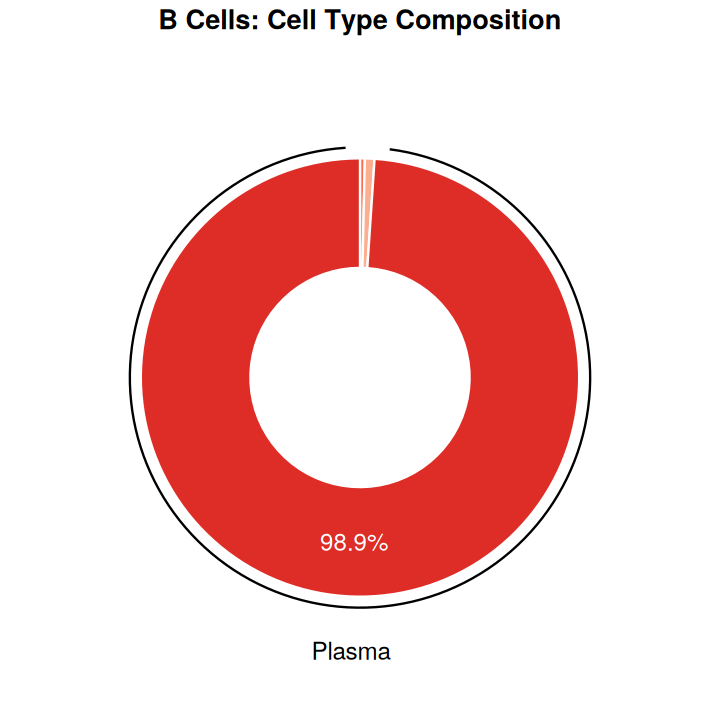

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(sub, vars = c("cluster_coarse", "cluster_fine")) %>%
  group_by(cluster_coarse) %>%
  summarise(prop = n() / nrow(.), .groups = "drop") %>%
  arrange(prop) %>%
  mutate(
    ymax = cumsum(prop),
    ymin = lag(ymax, default = 0),
    label = case_match(
      as.character(cluster_coarse),
      "B_naive" ~ "Naive",
      "B_memory" ~ "Memory",
      "B_plasma" ~ "Plasma"
    ),
    mid = (ymax + ymin) / 2
  )

plot <- ggplot(data, aes(ymin = ymin, ymax = ymax, fill = cluster_coarse)) +
  geom_rect(aes(xmin = 2, xmax = 4), colour = "white", show.legend = FALSE) +
  geom_segment(
    data = data %>% filter(prop > 0.02),
    mapping = aes(x = 4.2, xend = 4.2, y = ymin + 0.01, yend = ymax - 0.01),
  ) +
  geom_text(
    data = data %>% filter(prop > 0.02),
    aes(x = 3, y = mid, label = paste0(round(prop * 100, 1), "%")),
    colour = "white",
    size = 5,
    hjust = 0.5
  ) +
  geom_text(
    data = data %>% filter(prop > 0.02),
    aes(x = 5, y = mid, label = label),
    parse = TRUE, fontface = "bold", size = 5
  ) +
  labs(title = "B Cells: Cell Type Composition") +
  coord_polar(theta = "y") +
  xlim(0, 5) +
  scale_fill_manual(values = cluster.pal) +
  theme_void() +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/lesion_rims_lymphocytes_b_cell_type_donut.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Intralesional niche ASC signature comparison

In [ ]:
chosen.gep <- Features(sub[["GEP"]])[c(10, 11, 12)]
chosen.gep

[1] "IgA+ ASC (IGHA1/JCHAIN/MZB1)"    "IgG+ ASC (IGHG1/JCHAIN/MZB1)"   
[3] "Early ASC (TNFRSF17/PRDM1/TOX2)"

In [ ]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

In [ ]:
data <- FetchData(sub, vars = c("cluster_coarse", "diagnosis", "lesion_type", "program_score", "age", "sex", "donor_id")) %>%
  mutate(
    lesion_type = factor(lesion_type, levels = c("Core", "CA", "CI", "NAWM", "Ctrl"))
  )

# *** TOO FEW CELLS PER DONOR TO AGGREGATE ***
# data.summary <- data %>%
#   group_by(lesion_type, donor_id) %>%
#   summarise(
#     n_cells = n(),
#     composite_score = mean(composite_score, na.rm = TRUE),
#     age = first(age),
#     sex = first(sex),
#     .groups = "drop"
#   ) %>%
#   filter(n_cells >= 10)

In [ ]:
model <- lmerTest::lmer(
  program_score ~ lesion_type + age + sex + (1 | donor_id),
  data = data
)

In [ ]:
emm <- emmeans::emmeans(model, ~lesion_type, lmer.df = "Satterthwaite")

contrasts <- list(
  "Core vs CA" = c(1, -1, 0, 0),
  "Core vs CI" = c(1, 0, -1, 0),
  "Core vs NAWM" = c(1, 0, 0, -1),
  "CA vs CI" = c(0, 1, -1, 0),
  "CA vs NAWM" = c(0, 1, 0, -1),
  "CI vs NAWM" = c(0, 0, 1, -1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 4)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = c(0.55, 0.65, 0.85, 1.05, 0.55, 0.75)
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Core vs CA,-0.038245733,0.04838142,10.954390,-0.14478664,0.06829518,-0.79050452,0.4460096,0.9250497,p = 0.925 ns,Core,CA,0.55
Core vs CI,-0.004524097,0.04667222,8.410202,-0.11124352,0.10219532,-0.09693341,0.9250497,0.9250497,p = 0.925 ns,Core,CI,0.65
Core vs NAWM,-0.028382207,0.06139360,23.877467,-0.15512679,0.09836238,-0.46229910,0.6480518,0.9250497,p = 0.925 ns,Core,NAWM,0.85
CA vs CI,0.033721635,0.02182918,9.773767,-0.01506984,0.08251311,1.54479640,0.1541314,0.9247886,p = 0.925 ns,CA,CI,1.05
CA vs NAWM,0.009863526,0.03834913,220.278405,-0.06571463,0.08544168,0.25720337,0.7972619,0.9250497,p = 0.925 ns,CA,NAWM,0.55
CI vs NAWM,-0.023858110,0.04298573,70.031444,-0.10958976,0.06187354,-0.55502398,0.5806468,0.9250497,p = 0.925 ns,CI,NAWM,0.75


In [ ]:
contrasts <- list(
  "Core vs CA" = c(1, -1, -1, 0),
  "CI vs NAWM" = c(0, 1, 1, -1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 4)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.55
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Core vs CA,-0.1584607,0.04897841,8.154191,-0.27103447,-0.04588699,-3.235318,0.011659323,0.011659323,p = 0.0117 *,Core,CA,0.55
CI vs NAWM,0.1300785,0.04265560,85.169875,0.04527021,0.21488683,3.049507,0.003054282,0.006108564,p = 6.11e-03 **,CI,NAWM,0.55


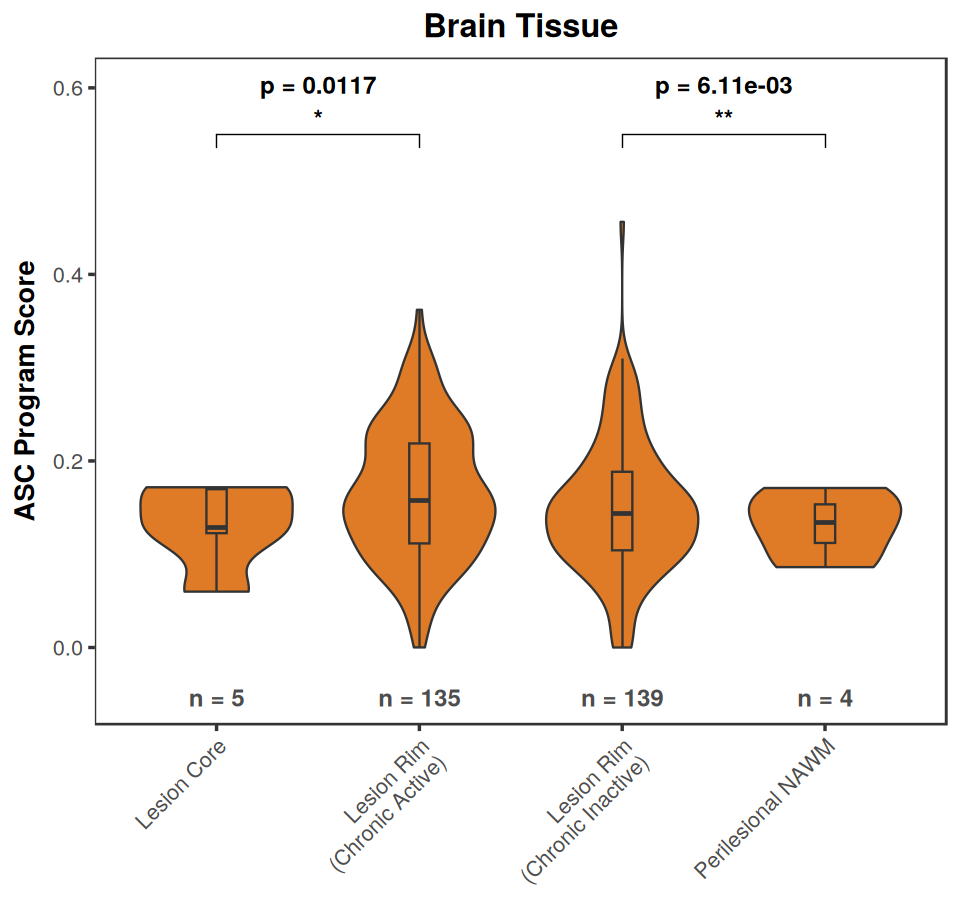

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 7.5)

ggplot(data = data, mapping = aes(x = lesion_type, y = program_score)) +
  geom_violin(
    mapping = aes(fill = diagnosis),
    width = 0.75,
    scale = "width",
    trim = TRUE,
    alpha = 1
  ) +
  geom_boxplot(
    mapping = aes(fill = diagnosis),
    width = 0.1,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_text(
    data = data %>%
      group_by(lesion_type) %>%
      summarise(n = n(), .groups = "drop"),
    mapping = aes(x = lesion_type, y = -Inf, label = paste0("n = ", n)),
    vjust = -1,
    size = 5,
    color = "grey30",
    fontface = "bold"
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.025,
    bracket.shorten = 0
  ) +
  scale_x_discrete(
    labels = c(
      "Core" = "Lesion Core",
      "CA" = "Lesion Rim\n(Chronic Active)",
      "CI" = "Lesion Rim\n(Chronic Inactive)",
      "NAWM" = "Perilesional NAWM",
      "Ctrl" = "Healthy WM"
    )
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.15, 0.15))) +
  scale_fill_manual(values = c(SPMS = "#df7b26", Control = "#74ad71")) +
  labs(
    title = "Brain Tissue",
    x = NULL,
    y = expression(bold(ASC ~ Program ~ Score))
  ) +
  theme_custom() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )

ggsave(
  filename = "../results/plots/lesion_rims_lymphocytes_asc_lesion_type_violin.pdf",
  width = 8,
  height = 7.5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Session Info

In [7]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] cowplot_1.1.3      patchwork_1.3.0    ggraph_2.2.1       igraph_2.0.3      
 [5] ggExtra_0.11.0     lubridate_1.9.3    forcats_1.0.0      stringr_1.5.1     
 [9] dplyr_1.1.4        purrr_1.0.2        readr_2.1.5        tidyr_1.3.1       
[13] tibble_3.2.1       ggplot2_3.5.1      tidyverse_2.0.0    future_1.34.0     
[17] Seurat_5.1.0       SeuratObject_5.0.2 sp_2.1-4          

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_1.8.9         magrittr_2.0.3        
  [4] TH.data_1.1-2          estimability_1.5.1    